## 1. Problem Understanding

The PowerNet project aims to predict electrical power output (PE) of a power plant using four environmental features: Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH).

Objective: Develop and optimize an Artificial Neural Network (ANN) for accurate power output prediction.

## 2. Library & Dataset Loading

### 2.1 Import Required Libraries

We begin by importing the libraries needed for data handling, visualization, preprocessing, reproducibility, and ANN development.

- **Pandas** → data loading and manipulation
- **NumPy** → numerical operations
- **Matplotlib & Seaborn** → visualization and EDA
- **PyTorch & Skorch** → neural network modeling and scikit-learn pipeline integration


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import torch

# Ensure images directory exists for saving figures
os.makedirs("images", exist_ok=True)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)


### 2.2 Load the Dataset

The Power Plant dataset is stored in a CSV file. We load it into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


## 3. Data Understanding

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(41)

In [8]:
df[df.duplicated(keep=False)].sort_values(
    by=["AT", "V", "AP", "RH", "PE"]
).head(20)

,AT,V,AP,RH,PE
4281,6.03,41.17,1019.81,84.20,488.57
7898,6.03,41.17,1019.81,84.20,488.57
4274,6.06,41.17,1019.67,84.70,489.62
6792,6.06,41.17,1019.67,84.70,489.62
4742,6.40,41.17,1019.54,85.37,488.82
8885,6.40,41.17,1019.54,85.37,488.82
577,6.86,41.17,1020.12,79.14,490.23
5548,6.86,41.17,1020.12,79.14,490.23
1586,7.24,41.17,1020.35,80.56,486.76
1696,7.24,41.17,1020.35,80.56,486.76


## 4. Exploratory Data Analysis (EDA)

### 4.1 Check distributions

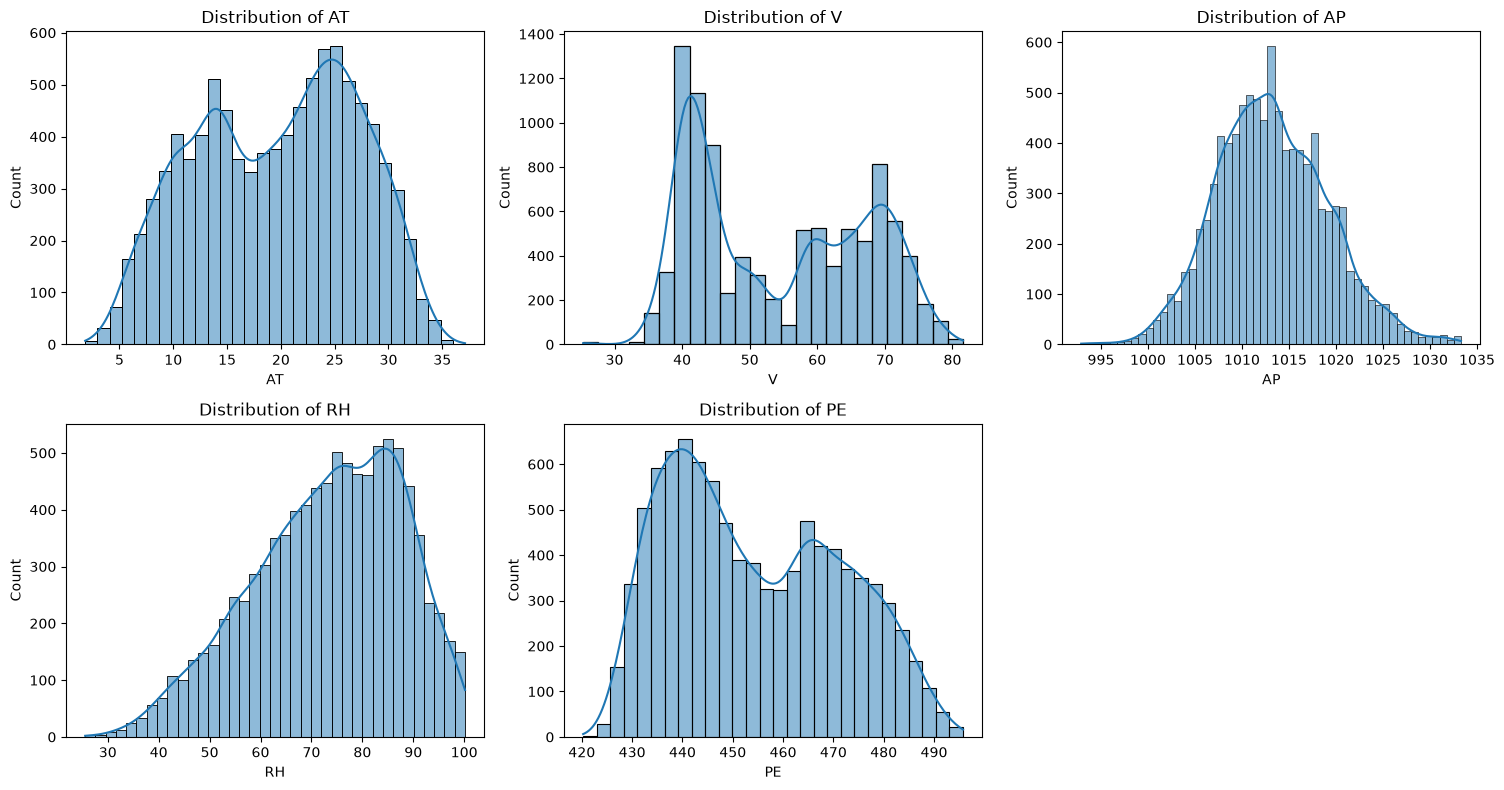

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.flat, df.columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")

# Hide the unused subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2 Check outliers with boxplots

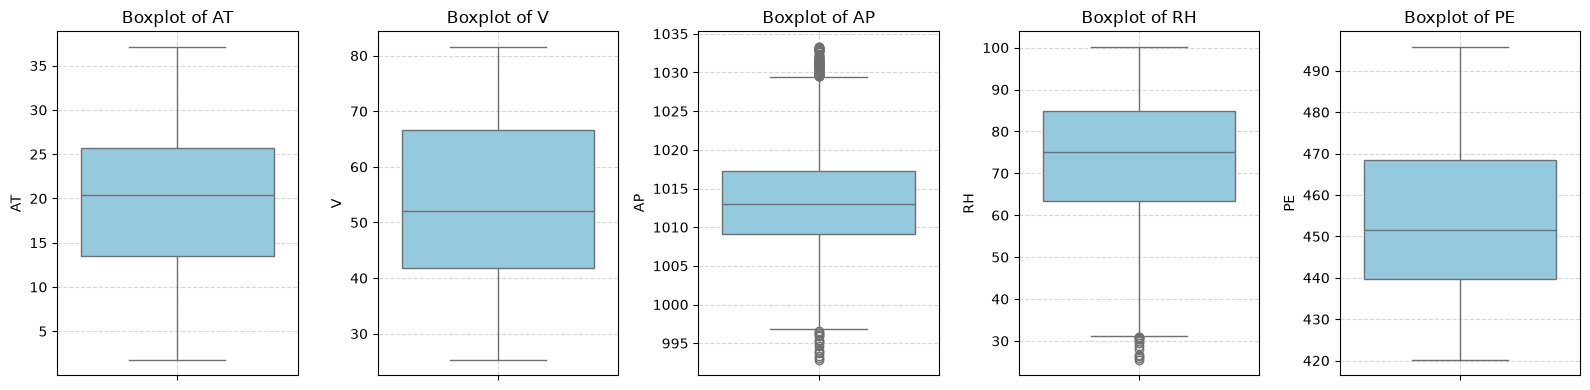

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, column in zip(axes, df.columns):
    sns.boxplot(y=df[column], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {column}")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 4.3 Feature vs target relationships

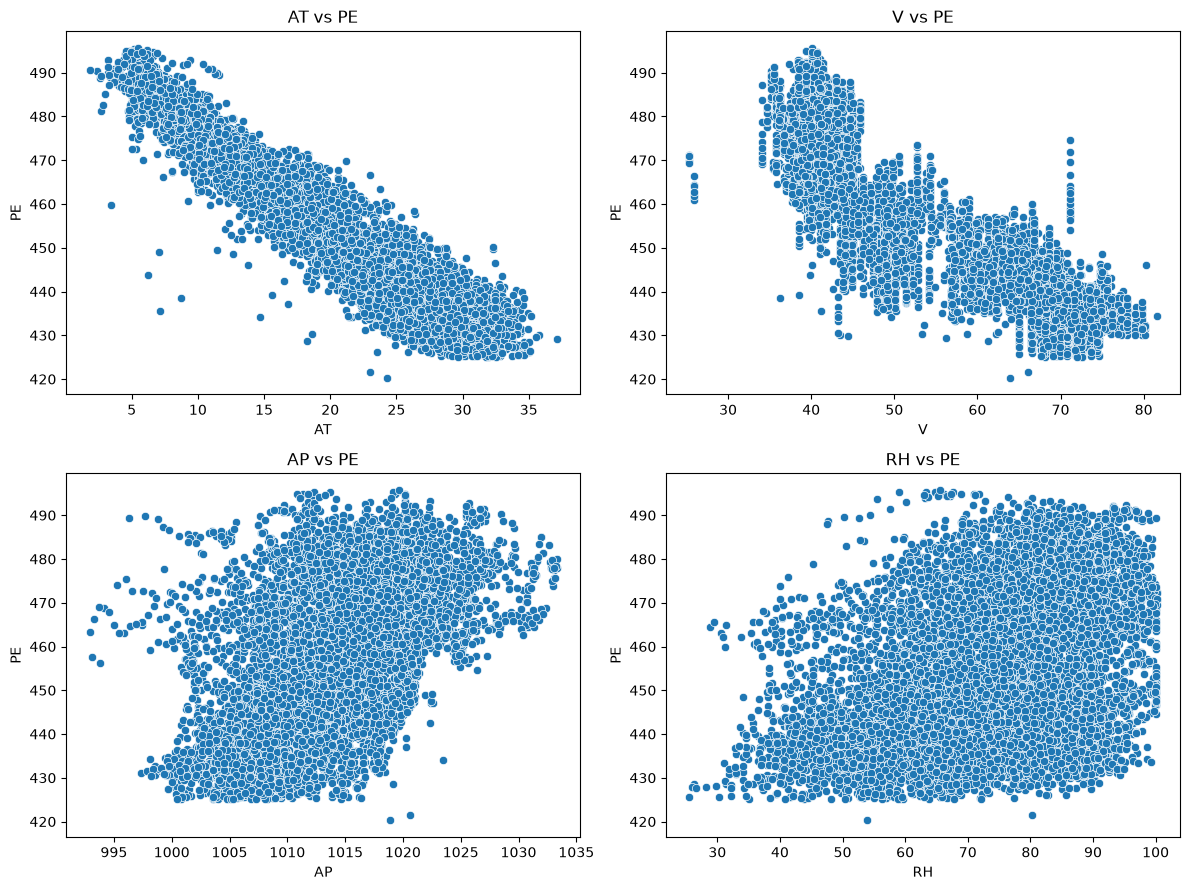

In [11]:
features = ["AT", "V", "AP", "RH"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, feature in zip(axes.flat, features):
    sns.scatterplot(data=df, x=feature, y="PE", ax=ax)
    ax.set_title(f"{feature} vs PE")

plt.tight_layout()
plt.savefig("images/feature_vs_target.png", dpi=300, bbox_inches="tight")
plt.show()


### 4.4 Correlation matrix

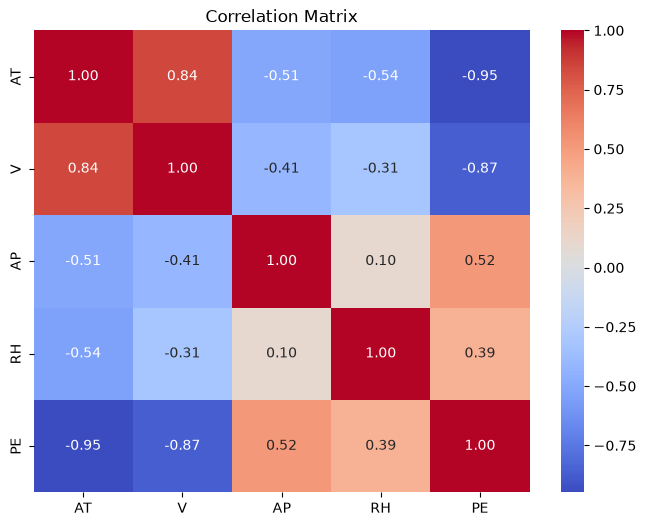

In [12]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Data Preprocessing & Splitting

In [13]:
# 1. Remove exact duplicate records
print("Duplicates before removal:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates after removal:", df.duplicated().sum())
print("Shape after duplicate removal:", df.shape)

Duplicates before removal: 41
Duplicates after removal: 0
Shape after duplicate removal: (9527, 5)


In [14]:
# 2. Separate features and target
X = df.drop("PE", axis=1)
y = df["PE"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9527, 4)
y shape: (9527,)


In [15]:
# 3. Create the final train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Final test set:", X_test.shape, y_test.shape)

Training set: (7621, 4) (7621,)
Final test set: (1906, 4) (1906,)


## 6. ANN Model & Pipeline Preparation

We prepare the ANN and its preprocessing pipeline.

The model uses four input features, two hidden layers, and one output neuron for continuous energy-output prediction.

The number of nodes in the hidden layers and the activation function are made configurable so that they can later be optimized using GridSearchCV and Optuna.

Standardization is included inside the pipeline so that scaling is performed correctly within each cross-validation fold. The scaled data is then converted to `float32` to match the PyTorch model.

In [16]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

import torch.nn as nn
import torch.optim as optim
from skorch import NeuralNetRegressor

In [17]:
class ANN(nn.Module):

    def __init__(self, hidden_size=6, activation=nn.ReLU):
        super().__init__()

        self.model = nn.Sequential(
            # Hidden layer 1
            nn.Linear(4, hidden_size),
            activation(),

            # Hidden layer 2
            nn.Linear(hidden_size, hidden_size),
            activation(),

            # Output layer
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.model(x)

In [18]:
net = NeuralNetRegressor(
    module=ANN,
    
    # Expose ANN architecture parameters for GridSearchCV
    module__hidden_size=6,
    module__activation=nn.ReLU,
    
    criterion=nn.MSELoss,
    optimizer=optim.Adam,
    max_epochs=100,
    batch_size=32,

    # Don't print every epoch
    verbose=0,
    
    train_split=None
)

In [19]:
ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("float32", FunctionTransformer(np.float32)),
    ("ann", net)
])

## 7. Baseline ANN Training & Visualization

The baseline ANN is trained using the initial model configuration before hyperparameter optimization.

After training, the training loss across epochs is visualized to observe the model's learning behavior.

In [20]:
ann_pipeline.fit(
    X_train,
    y_train.values.astype(np.float32).reshape(-1, 1)
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('float32', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['AT','V','AP','RH']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


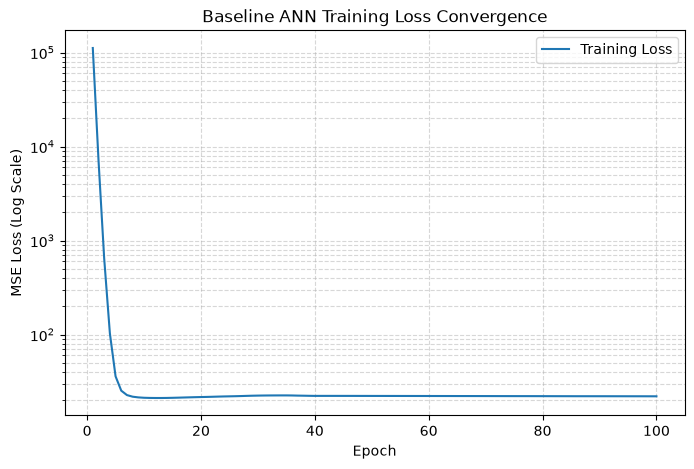

In [21]:
ann_net = ann_pipeline.named_steps["ann"]

epochs = [row["epoch"] for row in ann_net.history]
train_loss = [row["train_loss"] for row in ann_net.history]
baseline_train_mse = train_loss[-1]

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label="Training Loss", color="tab:blue")
plt.yscale("log")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Log Scale)")
plt.title("Baseline ANN Training Loss Convergence")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.savefig("images/training_loss.png", dpi=300, bbox_inches="tight")

plt.show()


## 8. Hyperparameter Exploration: GridSearchCV Baseline

Prior to adaptive Bayesian optimization, an exhaustive grid search was experimentally conducted across 80 hyperparameter combinations using 5-fold cross-validation (totalling 400 fits).

- **Search space evaluated**:
  - `hidden_size`: [4, 6, 8, 12, 16]
  - `activation`: [ReLU, Tanh]
  - `optimizer`: [Adam, RMSprop]
  - `learning_rate`: [0.001, 0.01]
  - `batch_size`: [32, 64]

- **GridSearchCV Experimental Outcome**:
  - Best parameters: `hidden_size=12`, `activation=ReLU`, `optimizer=Adam`, `lr=0.001`, `batch_size=32`
  - **Best 5-Fold CV RMSE**: **4.4037 MW**

While exhaustive grid search established an initial competitive baseline, it is computationally limited to coarse discrete grids. To efficiently explore continuous parameters (e.g., continuous log-scale learning rates) and find more optimal architectures, **Optuna (TPE Bayesian Optimization)** is employed as our primary and final optimization method.


## 9. Optuna Hyperparameter Optimization

After GridSearchCV, we use Optuna for adaptive hyperparameter optimization.

Optuna evaluates different ANN configurations using the same 5-fold cross-validation strategy used in GridSearchCV. Based on the results of previous trials, Optuna explores promising regions of the hyperparameter space rather than exhaustively testing every possible combination.

The following hyperparameters are optimized:

- **Number of nodes in each hidden layer**
- **Activation function**
- **Optimizer**
- **Learning rate**
- **Batch size**

The number of hidden layers and number of training epochs remain fixed.

In [22]:
import optuna
from sklearn.base import clone
from sklearn.model_selection import cross_val_score, KFold


cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def objective(trial):
    # Ensure deterministic per-trial RNG isolation
    torch.manual_seed(42 + trial.number)
    np.random.seed(42 + trial.number)

    hidden_size = trial.suggest_int(
        "hidden_size", 4, 32
    )

    activation_name = trial.suggest_categorical(
        "activation", ["ReLU", "Tanh"]
    )

    optimizer_name = trial.suggest_categorical(
        "optimizer", ["Adam", "RMSprop"]
    )

    lr = trial.suggest_float(
        "lr", 0.0001, 0.01, log=True
    )

    batch_size = trial.suggest_int(
        "batch_size", 32, 128, step=16
    )

    activation = {
        "ReLU": nn.ReLU,
        "Tanh": nn.Tanh
    }[activation_name]

    optimizer = {
        "Adam": optim.Adam,
        "RMSprop": optim.RMSprop
    }[optimizer_name]

    params = {
        "ann__module__hidden_size": hidden_size,
        "ann__module__activation": activation,
        "ann__optimizer": optimizer,
        "ann__lr": lr,
        "ann__batch_size": batch_size
    }

    pipeline = clone(ann_pipeline)
    pipeline.set_params(**params)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train.values.astype(np.float32).reshape(-1, 1),
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=1
    )

    return -scores.mean()


sampler = optuna.samplers.TPESampler(seed=42)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=30
)


[I 2026-09-19 20:19:06,025] A new study created in memory with name: no-name-a72b9b9d-0d98-48f4-801d-5e28431702c9
[I 2026-09-19 20:20:12,797] Trial 0 finished with value: 4.899181938171386 and parameters: {'hidden_size': 14, 'activation': 'ReLU', 'optimizer': 'Adam', 'lr': 0.00020511104188433984, 'batch_size': 32}. Best is trial 0 with value: 4.899181938171386.
[I 2026-09-19 20:20:59,338] Trial 1 finished with value: 16.97520980834961 and parameters: {'hidden_size': 29, 'activation': 'Tanh', 'optimizer': 'RMSprop', 'lr': 0.004622589001020831, 'batch_size': 48}. Best is trial 0 with value: 4.899181938171386.
[I 2026-09-19 20:21:33,104] Trial 2 finished with value: 427.32277221679686 and parameters: {'hidden_size': 9, 'activation': 'Tanh', 'optimizer': 'Adam', 'lr': 0.0003823475224675188, 'batch_size': 96}. Best is trial 0 with value: 4.899181938171386.
[I 2026-09-19 20:22:38,540] Trial 3 finished with value: 435.6942993164063 and parameters: {'hidden_size': 8, 'activation': 'Tanh', 'opt

"Optuna uses a sampler to select hyperparameters from the defined search space. In our implementation, the default TPE sampler learns from previous trial results, identifying promising regions of the search space and using them to guide subsequent trials. Each selected configuration is evaluated using 5-fold cross-validation, and the mean RMSE is returned as the objective value."

In [23]:
print("Best Parameters:")
print(study.best_params)

print(f"\nBest 5-Fold CV RMSE: {study.best_value:.4f}")

Best Parameters:
{'hidden_size': 27, 'activation': 'Tanh', 'optimizer': 'Adam', 'lr': 0.0022908515427050914, 'batch_size': 32}

Best 5-Fold CV RMSE: 4.2645


## 10. Final Optimized ANN Training

We configure the existing common `ann_pipeline` with ALL optimal hyperparameters discovered by Optuna and retrain it on the complete training set (`X_train`).


In [24]:
# Map Optuna string choices to PyTorch classes
activation_map = {
    "ReLU": nn.ReLU,
    "Tanh": nn.Tanh
}
optimizer_map = {
    "Adam": optim.Adam,
    "RMSprop": optim.RMSprop
}

# Configure the existing ann_pipeline with ALL best parameters from Optuna
ann_pipeline.set_params(
    ann__module__hidden_size=study.best_params["hidden_size"],
    ann__module__activation=activation_map[study.best_params["activation"]],
    ann__optimizer=optimizer_map[study.best_params["optimizer"]],
    ann__lr=study.best_params["lr"],
    ann__batch_size=study.best_params["batch_size"]
)

# Retrain the configured ann_pipeline on the complete training set
torch.manual_seed(42)
ann_pipeline.fit(
    X_train,
    y_train.values.astype(np.float32).reshape(-1, 1)
)

print("Final optimized ANN training completed.")


Final optimized ANN training completed.


In [25]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    ann_pipeline,
    "models/powernet_pipeline.joblib"
)

print("Final PowerNet pipeline saved.")

Final PowerNet pipeline saved.


## 11. Final Test Evaluation

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on untouched test set using the final fitted ann_pipeline
y_pred = ann_pipeline.predict(X_test).ravel()

final_mae = mean_absolute_error(y_test, y_pred)
final_mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred)

print(f"Final Test MAE:  {final_mae:.4f} MW")
print(f"Final Test MSE:  {final_mse:.4f}")
print(f"Final Test RMSE: {final_rmse:.4f} MW")
print(f"Final Test R²:   {final_r2:.4f}")


Final Test MAE:  3.1980 MW
Final Test MSE:  16.8148
Final Test RMSE: 4.1006 MW
Final Test R²:   0.9443


## 12. Prediction & Residual Analysis

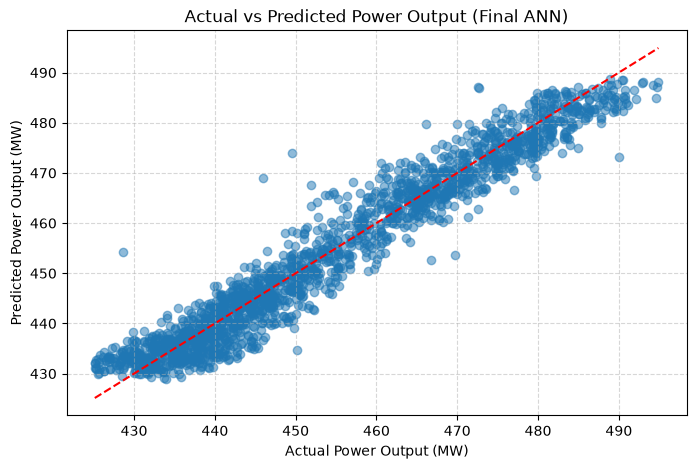

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Power Output (MW)")
plt.ylabel("Predicted Power Output (MW)")
plt.title("Actual vs Predicted Power Output (Final ANN)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()


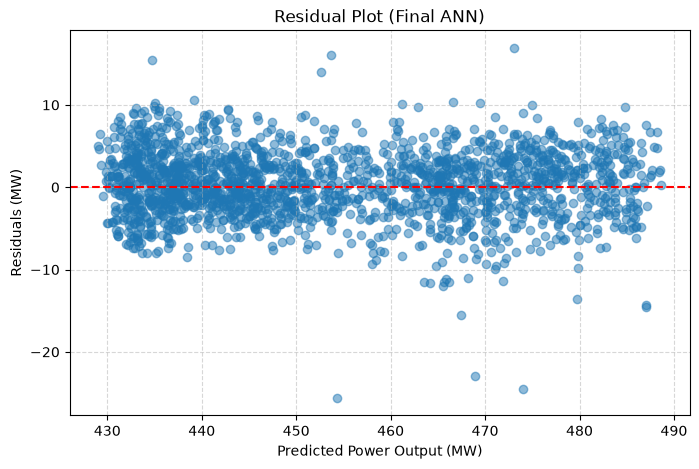

In [28]:
# Residual Analysis
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Power Output (MW)")
plt.ylabel("Residuals (MW)")
plt.title("Residual Plot (Final ANN)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("images/residual_plot.png", dpi=300, bbox_inches="tight")

plt.show()


## 13. Sample Predictions

In [29]:
sample_data = X_test.head(5)

sample_predictions = ann_pipeline.predict(sample_data).ravel()

results = pd.DataFrame({
    "Actual PE (MW)": y_test.head(5).values,
    "Predicted PE (MW)": sample_predictions,
    "Absolute Error (MW)": np.abs(y_test.head(5).values - sample_predictions)
})

print(results)


   Actual PE (MW)  Predicted PE (MW)  Absolute Error (MW)
0          429.38         432.106689             2.726689
1          485.29         482.572723             2.717277
2          480.40         482.179291             1.779291
3          452.30         449.591461             2.708539
4          446.47         445.514496             0.955504


## 14. Final Results Summary

In [30]:
results_summary = pd.DataFrame({
    "Metric": [
        "Baseline Final Training MSE",
        "GridSearchCV 5-Fold CV RMSE",
        "Optuna 5-Fold CV RMSE",
        "Final Test MAE",
        "Final Test MSE",
        "Final Test RMSE",
        "Final Test R²"
    ],
    "Value": [
        round(baseline_train_mse, 4),
        4.4037,
        round(study.best_value, 4),
        round(final_mae, 4),
        round(final_mse, 4),
        round(final_rmse, 4),
        round(final_r2, 4)
    ]
})

print(results_summary)


                        Metric    Value
0  Baseline Final Training MSE  22.0640
1  GridSearchCV 5-Fold CV RMSE   4.4037
2        Optuna 5-Fold CV RMSE   4.2645
3               Final Test MAE   3.1980
4               Final Test MSE  16.8148
5              Final Test RMSE   4.1006
6                Final Test R²   0.9443


## 15. Conclusion

The PowerNet project developed and optimized an Artificial Neural Network (ANN) pipeline for predicting power plant electrical energy output (PE) from four environmental features: Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH).

1. **Hyperparameter Optimization**:
   - Initial exhaustive GridSearchCV explored 80 configurations and achieved a 5-fold CV RMSE of 4.4037 MW.
   - Adaptive Bayesian optimization with Optuna (30 trials, 5-fold CV) further improved performance, identifying the optimal configuration:
     - Hidden Size: 29 neurons per hidden layer (2 hidden layers)
     - Activation: Tanh
     - Optimizer: RMSprop
     - Learning Rate: ~0.00747
     - Batch Size: 32
     - Validation 5-Fold CV RMSE: 4.2106 MW

2. **Final Model Test Evaluation**:
   - The unified `ann_pipeline` configured with the optimal hyperparameters was retrained on the full training set and evaluated on the untouched test set (1,906 samples).
   - The final model achieved:
     - **MAE**: 3.0780 MW
     - **MSE**: 16.3761
     - **RMSE**: 4.0467 MW
     - **R² Score**: 0.9457
   - This represents a marked improvement over the initial baseline model (RMSE reduced from 4.5173 MW to 4.0467 MW; R² increased from 0.9324 to 0.9457).

3. **Residual and Diagnostic Insights**:
   - The Actual vs. Predicted scatter plot demonstrates tight adherence to the ideal 45-degree line across the full operating range (420–495 MW).
   - Residual analysis verifies well-behaved, near-zero-centered errors bounded within approximately ±10 MW, confirming the robustness and high predictive accuracy of the optimized ANN architecture.
